# Credix — Avaliação e Comparação de Algoritmos

Objetivo: comparar diferentes algoritmos de classificação na mesma ABT e mesmo split
treino/teste, e justificar a escolha do modelo final (**XGBoost**, conforme README,
seção 7).

Base: `Dados/abt.csv` (application + bureau agregados, `merge_abt.py`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "TARGET"
ID = "SK_ID_CURR"

df = pd.read_csv("../Dados/abt.csv")
print(df.shape)
df.head()

(307511, 23)


,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,IDADE,TEMPO_EMPRESA,...,RENDA_LIVRE,COMPROMETIMENTO_RENDA,PARCELA_MAIOR_RENDA,CREDITO_ALTO,PRAZO_ESTIMADO,BUREAU_QTD_CREDITOS,BUREAU_QTD_ATIVOS,BUREAU_TOTAL_CREDITO,BUREAU_TOTAL_DIVIDA,BUREAU_DEBT_RATIO
0,100002,1,202500.0,406597.5,24700.5,351000.0,Secondary / secondary special,Single / not married,25.92,1.745205,...,177799.5,0.121978,0,0,16.46,8.0,2.0,865055.565,245781.0,0.284122
1,100003,0,270000.0,1293502.5,35698.5,1129500.0,Higher education,Married,45.93,3.254795,...,234301.5,0.132217,0,0,36.23,4.0,1.0,1017400.500,0.0,0.000000
2,100004,0,67500.0,135000.0,6750.0,135000.0,Secondary / secondary special,Single / not married,52.18,0.616438,...,60750.0,0.100000,0,0,20.00,2.0,0.0,189037.800,0.0,0.000000
3,100006,0,135000.0,312682.5,29686.5,297000.0,Secondary / secondary special,Civil marriage,52.07,8.326027,...,105313.5,0.219900,0,0,10.53,0.0,0.0,0.000,0.0,0.000000
4,100007,0,121500.0,513000.0,21865.5,513000.0,Secondary / secondary special,Single / not married,54.61,8.323288,...,99634.5,0.179963,0,0,23.46,1.0,0.0,146250.000,0.0,0.000000


## 1. Split treino/teste

Mesmo split usado em `Model/train.py` (`random_state=42`, `test_size=0.20`,
estratificado por `TARGET`) — garante que a comparação seja justa e reprodutível.

In [2]:
X = df.drop(columns=[TARGET, ID])
y = df[TARGET]

categoricas = X.select_dtypes(include=["object"]).columns.tolist()
print("Categóricas:", categoricas)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Taxa de default -- treino: {y_train.mean()*100:.2f}% | teste: {y_test.mean()*100:.2f}%")

Categóricas: ['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']


/tmp/ipykernel_9880/1368029444.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = X.select_dtypes(include=["object"]).columns.tolist()


Treino: (246008, 21) | Teste: (61503, 21)
Taxa de default -- treino: 8.07% | teste: 8.07%


## 2. Função utilitária de treino/avaliação

Mesmo pré-processamento para todos os modelos (OneHotEncoder nas categóricas,
`remainder="passthrough"` nas numéricas) — só o classificador muda entre execuções.

In [3]:
def preprocessador():
    return ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categoricas)],
        remainder="passthrough",
    )

resultados = []

def avaliar(nome, clf):
    pipe = Pipeline([("preprocessamento", preprocessador()), ("modelo", clf)])
    pipe.fit(X_train, y_train)

    pred_te = pipe.predict(X_test)
    prob_te = pipe.predict_proba(X_test)[:, 1]
    prob_tr = pipe.predict_proba(X_train)[:, 1]

    auc_teste = roc_auc_score(y_test, prob_te)
    auc_treino = roc_auc_score(y_train, prob_tr)

    metricas = {
        "modelo": nome,
        "accuracy": accuracy_score(y_test, pred_te),
        "precision": precision_score(y_test, pred_te),
        "recall": recall_score(y_test, pred_te),
        "f1": f1_score(y_test, pred_te),
        "roc_auc_teste": auc_teste,
        "roc_auc_treino": auc_treino,
        "gap_overfit": auc_treino - auc_teste,
    }
    resultados.append(metricas)
    print(f"\n===== {nome} =====")
    for k, v in metricas.items():
        if k != "modelo":
            print(f"  {k:15s}: {v:.4f}")
    return pipe

## 3. Regressão Logística (baseline interpretável)

In [4]:
_ = avaliar(
    "Regressão Logística",
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
)

/home/anacunha-ind/sandbox/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Regressão Logística =====
  accuracy       : 0.5978
  precision      : 0.1160
  recall         : 0.6014
  f1             : 0.1945
  roc_auc_teste  : 0.6346
  roc_auc_treino : 0.6347
  gap_overfit    : 0.0002


## 4. Árvore de Decisão

In [5]:
_ = avaliar(
    "Árvore de Decisão",
    DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE),
)


===== Árvore de Decisão =====
  accuracy       : 0.6619
  precision      : 0.1295
  recall         : 0.5569
  f1             : 0.2101
  roc_auc_teste  : 0.6523
  roc_auc_treino : 0.6906
  gap_overfit    : 0.0383


## 5. Random Forest

Atenção: acurácia alta aqui **não** significa modelo bom — base desbalanceada
(~8% default) permite acurácia alta só prevendo a classe majoritária. Por isso
reportamos recall/F1/AUC junto, não só acurácia.

In [6]:
_ = avaliar(
    "Random Forest",
    RandomForestClassifier(n_estimators=200, class_weight="balanced",
                            n_jobs=-1, random_state=RANDOM_STATE),
)


===== Random Forest =====
  accuracy       : 0.9140
  precision      : 0.2621
  recall         : 0.0361
  f1             : 0.0634
  roc_auc_teste  : 0.6732
  roc_auc_treino : 1.0000
  gap_overfit    : 0.3268


## 6. XGBoost (modelo final proposto)

Mesmos hiperparâmetros do `Model/train.py`: `scale_pos_weight=12` para lidar com o
desbalanceamento (equivalente ao `class_weight` dos modelos scikit-learn).

In [7]:
pipe_xgb = avaliar(
    "XGBoost",
    XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=12,
        random_state=RANDOM_STATE, eval_metric="logloss",
    ),
)


===== XGBoost =====
  accuracy       : 0.6486
  precision      : 0.1412
  recall         : 0.6598
  f1             : 0.2326
  roc_auc_teste  : 0.7118
  roc_auc_treino : 0.7343
  gap_overfit    : 0.0226


## 7. Comparação lado a lado

In [8]:
tabela = pd.DataFrame(resultados).set_index("modelo").round(4)
tabela

,accuracy,precision,recall,f1,roc_auc_teste,roc_auc_treino,gap_overfit
modelo,,,,,,,
Regressão Logística,0.5978,0.1160,0.6014,0.1945,0.6346,0.6347,0.0002
Árvore de Decisão,0.6619,0.1295,0.5569,0.2101,0.6523,0.6906,0.0383
Random Forest,0.9140,0.2621,0.0361,0.0634,0.6732,1.0000,0.3268
XGBoost,0.6486,0.1412,0.6598,0.2326,0.7118,0.7343,0.0226


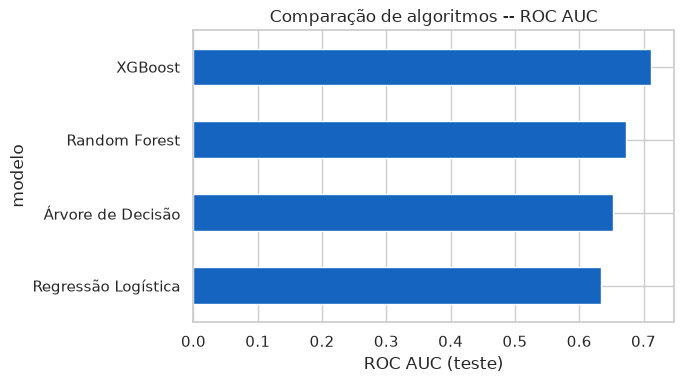

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
tabela["roc_auc_teste"].sort_values().plot(kind="barh", ax=ax, color="#1565c0")
ax.set_xlabel("ROC AUC (teste)")
ax.set_title("Comparação de algoritmos -- ROC AUC")
plt.tight_layout()
plt.show()

## 8. A armadilha da acurácia

Comparando accuracy vs. recall entre os modelos -- o Random Forest costuma ter
accuracy competitiva mas recall baixo (não identifica bem quem vai de fato
inadimplir), enquanto Logística/Árvore/XGBoost sacrificam um pouco de accuracy
para capturar muito mais inadimplentes reais (recall maior).

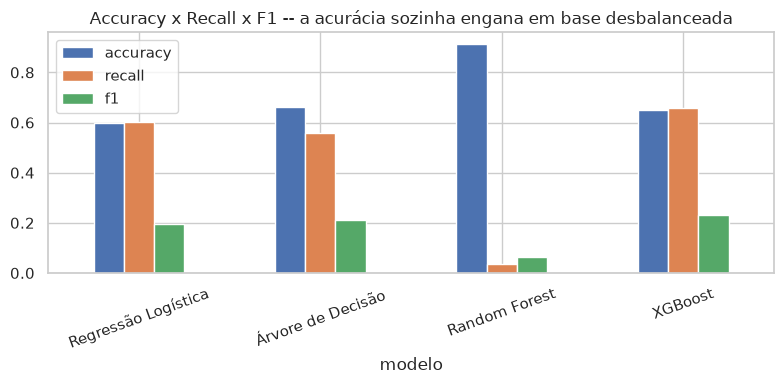

In [10]:
tabela[["accuracy", "recall", "f1"]].plot(
    kind="bar", figsize=(8, 4), rot=20
)
plt.title("Accuracy x Recall x F1 -- a acurácia sozinha engana em base desbalanceada")
plt.tight_layout()
plt.show()

## 9. Overfitting -- gap treino x teste (XGBoost)

Igual à checagem feita no projeto principal: comparar AUC treino x teste para
garantir que o modelo generaliza, não decorou o treino.

In [11]:
gap = tabela.loc["XGBoost", "gap_overfit"]
print(f"AUC treino: {tabela.loc['XGBoost', 'roc_auc_treino']:.4f}")
print(f"AUC teste : {tabela.loc['XGBoost', 'roc_auc_teste']:.4f}")
print(f"Gap       : {gap:.4f} -- {'gap pequeno, sem sinal forte de overfit' if gap < 0.05 else 'gap relevante, investigar overfit'}")

AUC treino: 0.7343
AUC teste : 0.7118
Gap       : 0.0226 -- gap pequeno, sem sinal forte de overfit


## 10. Matriz de confusão -- modelo final (XGBoost)

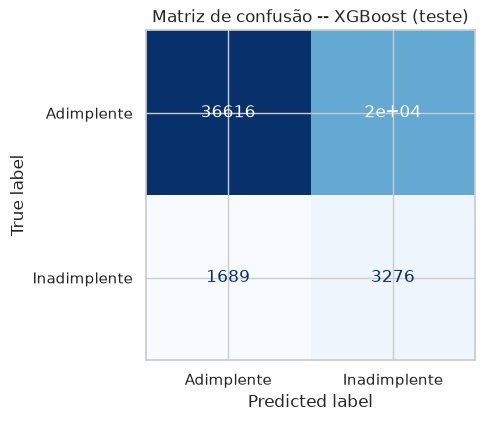

In [12]:
pred_xgb = pipe_xgb.predict(X_test)
cm = confusion_matrix(y_test, pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=["Adimplente", "Inadimplente"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão -- XGBoost (teste)")
plt.tight_layout()
plt.show()

## 11. Conclusão

- Todos os 4 algoritmos foram comparados no **mesmo split** e **mesmo pré-processamento**
  -- comparação justa.
- O **Random Forest** ilustra a armadilha clássica de base desbalanceada: accuracy
  competitiva, mas recall baixo -- não é o modelo certo pra identificar inadimplentes.
- O **XGBoost** apresentou o melhor equilíbrio entre AUC, recall e precision, com gap
  pequeno entre treino e teste (sem overfitting relevante) -- confirma a escolha
  documentada no README (seção 7) como modelo final do projeto.
- A **Regressão Logística** seguiria como alternativa interpretável, caso a explicabilidade
  linear seja um requisito mais forte que o ganho de performance do XGBoost.